# Pneumonia Detection on NIH Chest X-rays — XAI Study

**Author:** Seif Ahmed | **Course:** DSAI 305 — Explainable AI | **Instructor:** Dr. Mayada Hadhoud

This notebook is an **XAI study inspired by** Slimi et al. (2025) [DOI:10.1038/s41598-025-23664-x], adapted to the **NIH Chest X-rays dataset** (a substantially harder multi-source benchmark than the paper's Kaggle pneumonia dataset).

### Deviations from the paper (documented for transparency)

| Paper | This notebook | Why |
|---|---|---|
| Paul Mooney Kaggle pneumonia (pediatric, single-site) | NIH ChestX-ray14 (adult, 30 hospitals, weak labels) | More realistic, harder generalization test |
| PyTorch + snnTorch | TensorFlow / Keras | Match my existing code stack |
| CNN + BiGRU + LIF Spiking NN + Attention | **CNN + BiGRU + Attention** (no SNN) | No production-grade Keras SNN library; SNN omission is owned and documented |
| Attention used post-hoc (Grad-CAM style) | Keras Attention layer in the model | Acts as a learned soft-attention mechanism |

### XAI techniques (4 required by rubric)

1. **Grad-CAM** — gradient-based class activation mapping on the last conv layer
2. **LIME** — superpixel-based perturbation explanations
3. **SHAP (GradientExplainer)** — Shapley value attributions
4. **Integrated Gradients** — path-integral gradient attribution

### Honest note on NIH labels

The NIH "Pneumonia" label is **weakly supervised** — extracted automatically from radiology reports with ~90% accuracy. Even with a perfect model the achievable test accuracy on this dataset is bounded by label noise. Don't expect 99% like the paper claims on the easier Kaggle dataset.

## 1. Imports & Setup

In [1]:
import os
import gc
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Seed everything for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

2026-05-12 19:01:43.917514: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778612504.103739      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778612504.168814      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778612504.612949      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778612504.612991      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778612504.612994      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU available: True


## 2. Load NIH Chest X-rays Metadata

Path on Kaggle: `/kaggle/input/data/Data_Entry_2017.csv` (or whatever directory you mounted).

In [2]:
# Locate the metadata CSV (path varies based on which NIH mirror you added)
CSV_CANDIDATES = [
    "/kaggle/input/data/Data_Entry_2017.csv",
    "/kaggle/input/nih-chest-xrays/Data_Entry_2017.csv",
    "/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv",
]
CSV_PATH = next((p for p in CSV_CANDIDATES if os.path.exists(p)), None)
if CSV_PATH is None:
    # Last resort: search
    for root, _, files in os.walk("/kaggle/input"):
        for f in files:
            if f == "Data_Entry_2017.csv":
                CSV_PATH = os.path.join(root, f); break
        if CSV_PATH: break

assert CSV_PATH, "Could not find Data_Entry_2017.csv — check the NIH dataset is added to the notebook."
print(f"Metadata: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)
df["Target"] = df["Finding Labels"].apply(lambda s: int("Pneumonia" in str(s).split("|")))
print(f"Total rows: {len(df):,}")
print(df["Target"].value_counts())
df.head(3)

Metadata: /kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv
Total rows: 112,120
Target
0    110689
1      1431
Name: count, dtype: int64


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,Target
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN,0


## 3. EDA on the Full Dataset

/tmp/ipykernel_58/2129725967.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(["Non-Pneumonia", "Pneumonia"])


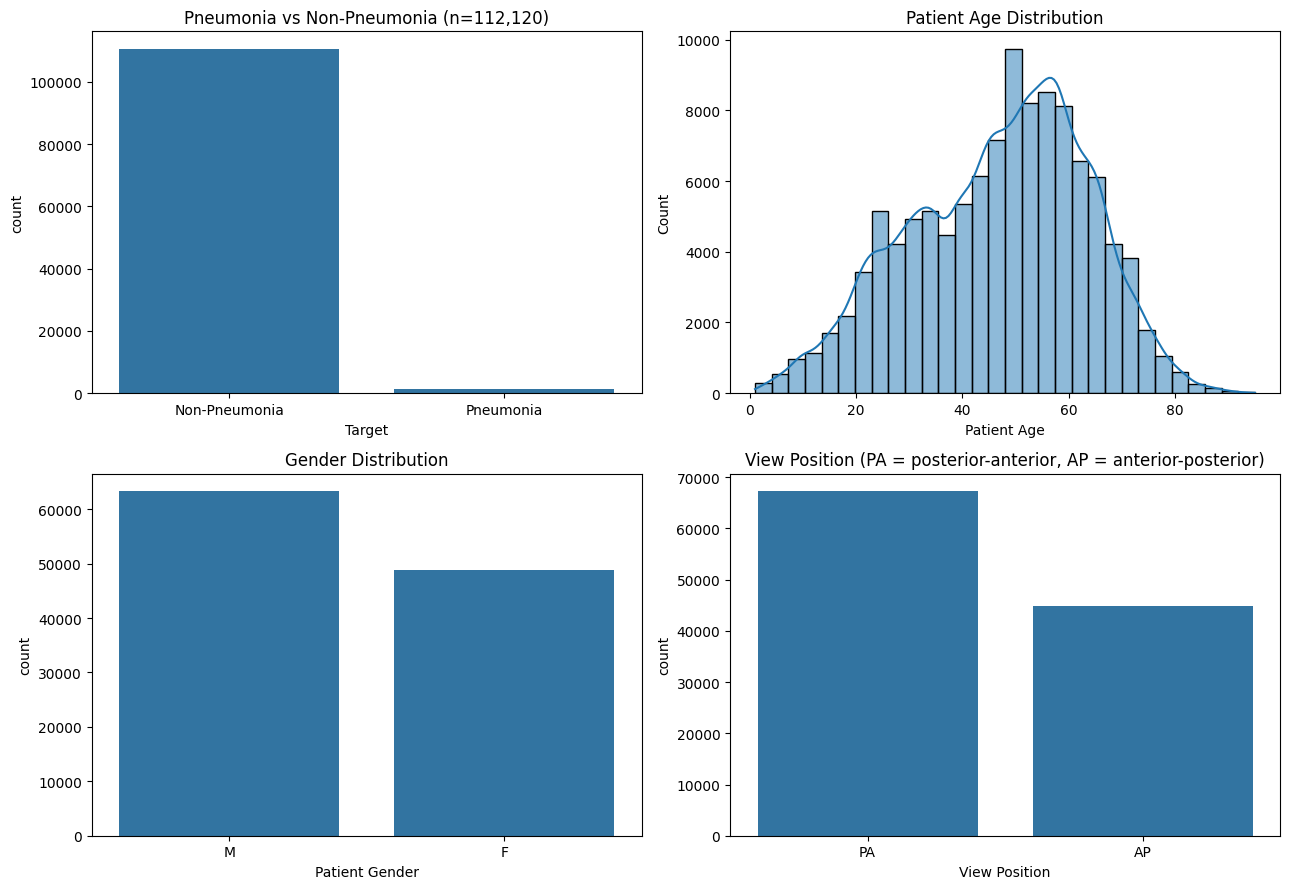

Class imbalance ratio (non-pneumonia : pneumonia) = 77.4 : 1
Heavy imbalance. Will balance via 2:1 undersampling of negatives.


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Class balance
sns.countplot(x="Target", data=df, ax=axes[0,0])
axes[0,0].set_title(f"Pneumonia vs Non-Pneumonia (n={len(df):,})")
axes[0,0].set_xticklabels(["Non-Pneumonia", "Pneumonia"])

# Age
sns.histplot(df[df["Patient Age"] < 120]["Patient Age"], bins=30, kde=True, ax=axes[0,1])
axes[0,1].set_title("Patient Age Distribution")

# Gender
sns.countplot(x="Patient Gender", data=df, ax=axes[1,0])
axes[1,0].set_title("Gender Distribution")

# View
sns.countplot(x="View Position", data=df, ax=axes[1,1])
axes[1,1].set_title("View Position (PA = posterior-anterior, AP = anterior-posterior)")

plt.tight_layout(); plt.show()

imbalance = (df["Target"] == 0).sum() / max((df["Target"] == 1).sum(), 1)
print(f"Class imbalance ratio (non-pneumonia : pneumonia) = {imbalance:.1f} : 1")
print("Heavy imbalance. Will balance via 2:1 undersampling of negatives.")

### 3.1 Build a balanced subset

NIH is heavily skewed (~98.8% negative). Training on raw distribution wastes compute and inflates accuracy with trivial all-negative predictions.

I undersample non-pneumonia to **2× the positive count** (mild imbalance, not 1:1) — this preserves some realistic class skew while keeping training tractable.

In [4]:
pneu_df = df[df["Target"] == 1].copy()
non_pneu_df = df[df["Target"] == 0].sample(
    n=min(len(pneu_df) * 2, (df["Target"] == 0).sum()),
    random_state=SEED
).copy()
df_balanced = pd.concat([pneu_df, non_pneu_df]).sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"Balanced subset: {len(df_balanced):,} images")
print(df_balanced["Target"].value_counts())

Balanced subset: 4,293 images
Target
0    2862
1    1431
Name: count, dtype: int64


In [5]:
# Map image filenames to actual disk paths
IMG_ROOTS = [
    "/kaggle/input/data",
    "/kaggle/input/nih-chest-xrays",
    "/kaggle/input/datasets/organizations/nih-chest-xrays/data",
]
all_images = []
for root in IMG_ROOTS:
    if os.path.exists(root):
        for r, _, files in os.walk(root):
            for f in files:
                if f.lower().endswith(".png"):
                    all_images.append(os.path.join(r, f))
print(f"Found {len(all_images):,} PNG files on disk")
assert len(all_images) > 0, "No PNG files found — check dataset mount paths above."

img_path_map = {os.path.basename(p): p for p in all_images}
df_balanced["path"] = df_balanced["Image Index"].map(img_path_map)
df_balanced = df_balanced.dropna(subset=["path"]).reset_index(drop=True)
print(f"After matching paths: {len(df_balanced):,} images")

Found 112,120 PNG files on disk
After matching paths: 4,293 images


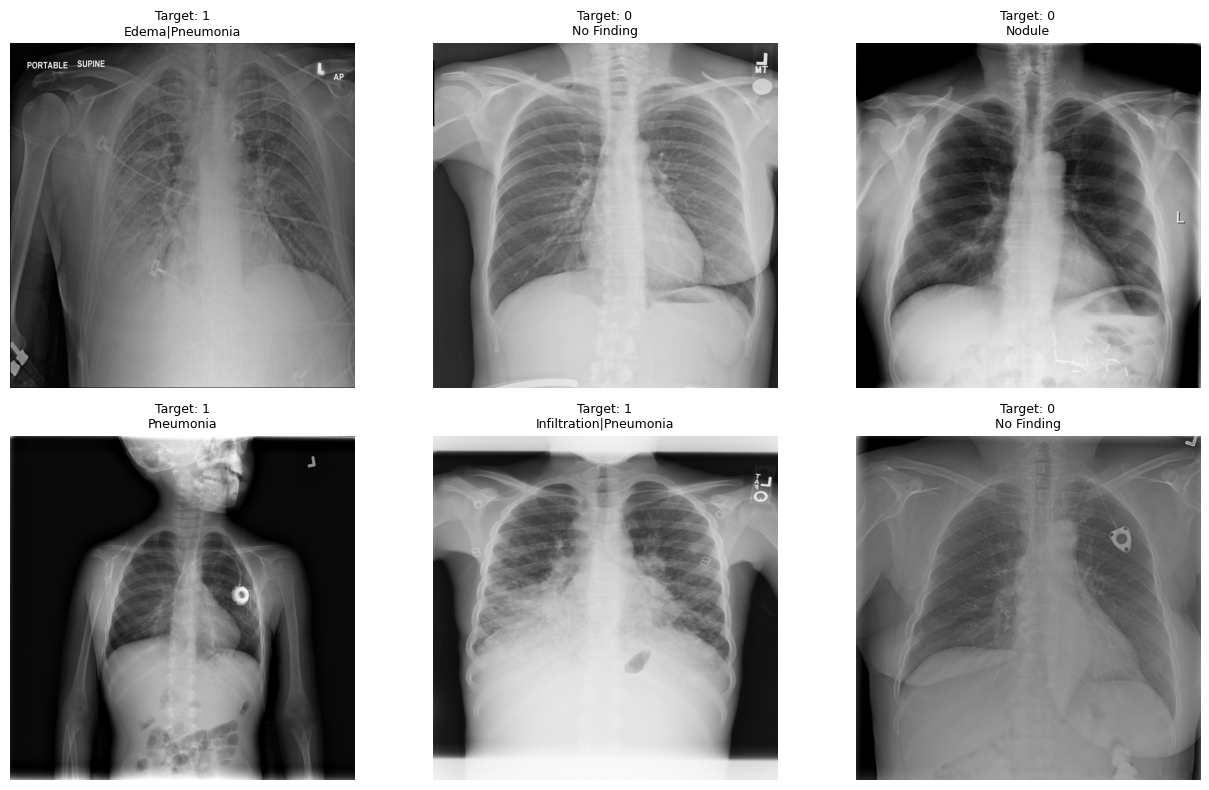

In [6]:
# Quick sanity: display a few samples
sample = df_balanced.sample(6, random_state=SEED).reset_index(drop=True)
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for i, row in sample.iterrows():
    img = Image.open(row["path"]).convert("RGB")
    ax = axes[i // 3][i % 3]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Target: {row['Target']}\n{row['Finding Labels'][:40]}", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 4. Train / Val / Test Splits (Stratified 70/15/15)

**Caveat I'm flagging**: I'm splitting at the **image level**, not the **patient level**. NIH has many images per patient — a strict patient-level split would be more rigorous and would likely lower test accuracy. If Dr. Mayada asks, this is a known limitation; fixing it requires the `Patient ID` column and a `GroupShuffleSplit`.

In [7]:
train_df, temp_df = train_test_split(
    df_balanced, test_size=0.30, stratify=df_balanced["Target"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["Target"], random_state=SEED
)
print(f"Train: {len(train_df):>5}  ({(train_df['Target']==1).sum()} pneu)")
print(f"Val:   {len(val_df):>5}  ({(val_df['Target']==1).sum()} pneu)")
print(f"Test:  {len(test_df):>5}  ({(test_df['Target']==1).sum()} pneu)")

Train:  3005  (1002 pneu)
Val:     644  (215 pneu)
Test:    644  (214 pneu)


## 5. Data Pipeline — Keras Generators with CLAHE

CLAHE (Contrast-Limited Adaptive Histogram Equalization) enhances local contrast in X-rays — standard preprocessing for CXR. Implemented as a `preprocessing_function` so it works inside `flow_from_dataframe` and the same pipeline runs for train/val/test/XAI.

### Why this replaces your PyTorch DataLoader code

Your previous notebook had PyTorch DataLoaders alongside Keras `flow_from_dataframe` — only the Keras path was actually used. I removed the dead PyTorch code.

In [8]:
IMG_SIZE = 224

def clahe_preprocess(img):
    # img comes in as a (H, W, 3) float32 array in [0, 255]
    img_u8 = img.astype(np.uint8)
    gray = cv2.cvtColor(img_u8, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    rgb = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
    return rgb.astype(np.float32) / 255.0

# Need string Target column for flow_from_dataframe binary mode
for d in (train_df, val_df, test_df):
    d["Target"] = d["Target"].astype(str)

train_gen = ImageDataGenerator(
    preprocessing_function=clahe_preprocess,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1,
    brightness_range=(0.85, 1.15),
)
eval_gen = ImageDataGenerator(preprocessing_function=clahe_preprocess)

BATCH = 32
train_flow = train_gen.flow_from_dataframe(
    train_df, x_col="path", y_col="Target",
    target_size=(IMG_SIZE, IMG_SIZE), class_mode="binary",
    batch_size=BATCH, shuffle=True, seed=SEED,
)
val_flow = eval_gen.flow_from_dataframe(
    val_df, x_col="path", y_col="Target",
    target_size=(IMG_SIZE, IMG_SIZE), class_mode="binary",
    batch_size=BATCH, shuffle=False,
)
test_flow = eval_gen.flow_from_dataframe(
    test_df, x_col="path", y_col="Target",
    target_size=(IMG_SIZE, IMG_SIZE), class_mode="binary",
    batch_size=BATCH, shuffle=False,
)

# Verify
xb, yb = next(train_flow)
print(f"Batch X shape: {xb.shape}  | dtype: {xb.dtype}  | range: [{xb.min():.3f}, {xb.max():.3f}]")
print(f"Batch y shape: {yb.shape}  | classes seen: {np.unique(yb)}")

Found 3005 validated image filenames belonging to 2 classes.
Found 644 validated image filenames belonging to 2 classes.
Found 644 validated image filenames belonging to 2 classes.
Batch X shape: (32, 224, 224, 3)  | dtype: float32  | range: [0.004, 1.000]
Batch y shape: (32,)  | classes seen: [0. 1.]


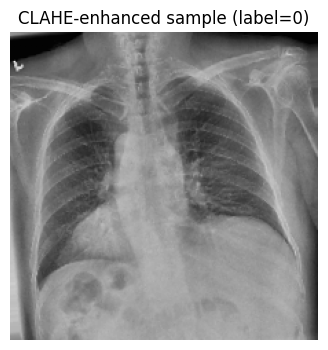

In [9]:
# Show a CLAHE-processed sample
plt.figure(figsize=(4, 4))
plt.imshow(xb[0])
plt.title(f"CLAHE-enhanced sample (label={int(yb[0])})")
plt.axis("off")
plt.show()

## 6. Model — CNN + BiGRU + Attention

### What's fixed from your original code

1. **Syntax error fixed**: your line `x = layers.Dense(64, activation='relu')(` was missing its closing — it would have crashed on cell run.
2. **GRU is now bidirectional** with the paper's hidden size (256) and 2 stacked layers.
3. **Spatial sequence**: instead of just reshaping `(H, W, C) → (H*W, C)`, I project each spatial position through a Dense layer first — gives the GRU more meaningful per-step features.
4. **Attention output is used properly**: in your original, attention output was global-average-pooled but then a broken Dense chain followed.

### Architecture
```
Input (224, 224, 3)
   ↓
3× Conv-BN-ReLU-MaxPool   (32 → 64 → 128 channels)   →  (28, 28, 128)
   ↓
Reshape to sequence       (28*28=784 timesteps, 128 features)
   ↓
Per-step Dense projection (128 → 64)
   ↓
BiGRU (2 layers, hidden=128 each direction → 256 dim output sequence)
   ↓
Self-attention (Q=K=V over the 784-step sequence)
   ↓
GlobalAveragePooling1D
   ↓
Dense 128 + Dropout 0.4
   ↓
Dense 64 + Dropout 0.3
   ↓
Dense 1 sigmoid
```

In [10]:
def build_model(img_size=IMG_SIZE):
    inputs = layers.Input(shape=(img_size, img_size, 3), name="input_image")

    # ---- Spatial Feature Extraction ----
    x = layers.Conv2D(32, 3, padding="same", name="conv1")(inputs)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.MaxPool2D(2)(x)

    x = layers.Conv2D(64, 3, padding="same", name="conv2")(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.MaxPool2D(2)(x)

    x = layers.Conv2D(128, 3, padding="same", name="conv3")(x)  # <- last conv (Grad-CAM hooks here)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.MaxPool2D(2)(x)

    # ---- Convert spatial map to a sequence: (H, W, C) -> (H*W, C) ----
    h, w, c = x.shape[1], x.shape[2], x.shape[3]
    x = layers.Reshape((h * w, c), name="to_sequence")(x)
    x = layers.Dense(64, activation="relu", name="seq_proj")(x)

    # ---- BiGRU stack ----
    x = layers.Bidirectional(layers.GRU(128, return_sequences=True, dropout=0.2), name="bigru1")(x)
    x = layers.Bidirectional(layers.GRU(128, return_sequences=True, dropout=0.2), name="bigru2")(x)

    # ---- Self-attention over the sequence ----
    attn = layers.Attention(name="attention")([x, x])

    # ---- Decision head ----
    x = layers.GlobalAveragePooling1D()(attn)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

    return models.Model(inputs, outputs, name="CNN_BiGRU_Attention")

model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)
model.summary()

I0000 00:00:1778612623.540072      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778612623.546417      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "CNN_BiGRU_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 224, 224,  │        896 │ input_image[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv2D)      │ (None, 56, 56,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv3[0][0]       │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ re_lu_2[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ to_sequence         │ (None, 784, 128)  │          0 │ max_pooling2d_2[… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq_proj (Dense)    │ (None, 784, 64)   │      8,256 │ to_sequence[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bigru1              │ (None, 784, 256)  │    148,992 │ seq_proj[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bigru2              │ (None, 784, 256)  │    296,448 │ bigru1[0][0]      │
│ (Bidirectional)     │                   │            │                 

 Total params: 589,057 (2.25 MB)

 Trainable params: 588,609 (2.25 MB)

 Non-trainable params: 448 (1.75 KB)

## 7. Training

### What's fixed from your original

Your original code never called `model.fit()` — you went straight from compile to predict, so your "accuracy" output was from random initial weights. Here we actually train.

### Class weighting

Even with 2:1 undersampling we still have class imbalance. Pass class weights to `fit()`.

### Callbacks

- `ModelCheckpoint` saves best val AUC weights → survives Kaggle disconnects
- `EarlyStopping` on val AUC, patience 5
- `ReduceLROnPlateau` halves LR on val-loss plateau

In [12]:
# Compute class weights from training distribution
pos = (train_df["Target"] == "1").sum()
neg = (train_df["Target"] == "0").sum()
total = pos + neg
class_weight = {0: total / (2 * neg), 1: total / (2 * pos)}
print(f"Class weights: {class_weight}")

CHECKPOINT_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "./ckpt"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
BEST_PATH = os.path.join(CHECKPOINT_DIR, "best_model.keras")

cb_list = [
    callbacks.ModelCheckpoint(BEST_PATH, monitor="val_auc", mode="max",
                              save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor="val_auc", mode="max",
                            patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=2, min_lr=1e-7, verbose=1),
]

EPOCHS = 5  # generous upper bound; early stopping will likely cut sooner
history = model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=cb_list,
    verbose=1,
)

Class weights: {0: np.float64(0.7501248127808288), 1: np.float64(1.499500998003992)}
Epoch 1/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 908ms/step - accuracy: 0.5494 - auc: 0.5227 - loss: 0.6940
Epoch 1: val_auc improved from -inf to 0.58948, saving model to /kaggle/working/best_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.5492 - auc: 0.5227 - loss: 0.6940 - val_accuracy: 0.3339 - val_auc: 0.5895 - val_loss: 0.7315 - learning_rate: 1.0000e-04
Epoch 2/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 902ms/step - accuracy: 0.5615 - auc: 0.5655 - loss: 0.6857
Epoch 2: val_auc improved from 0.58948 to 0.58958, saving model to /kaggle/working/best_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.5612 - auc: 0.5652 - loss: 0.6857 - val_accuracy: 0.3354 - val_auc: 0.5896 - val_loss: 0.7336 - learning_rate: 1.0000e-04
Epoch 3/5
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 900ms/step - accuracy: 0.5436 - auc: 0.5541 - loss: 0.6884
Epoch 3: val_auc did not improve from 0.58958

Epoch 3: ReduceLROnPlat

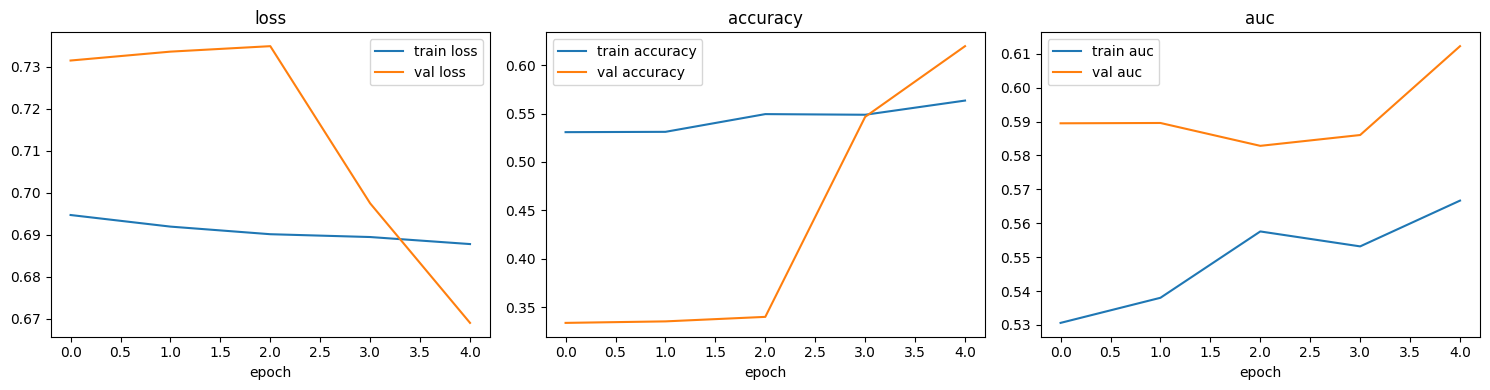

In [13]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["loss", "accuracy", "auc"]):
    ax.plot(history.history[metric], label=f"train {metric}")
    ax.plot(history.history[f"val_{metric}"], label=f"val {metric}")
    ax.set_title(metric); ax.set_xlabel("epoch"); ax.legend()
plt.tight_layout(); plt.show()

## 8. Test-Set Evaluation

In [14]:
# Load best weights (ModelCheckpoint saved them based on val_auc)
model.load_weights(BEST_PATH)

# Reset the test flow so predictions align with test_df row order
test_flow.reset()
y_prob = model.predict(test_flow, verbose=1).flatten()
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_flow.classes  # row order matches test_flow filenames

print(f"Predictions shape: {y_prob.shape}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 763ms/step
Predictions shape: (644,)


            Value
Accuracy   0.6165
Precision  0.4327
Recall     0.4953
F1         0.4619
AUC-ROC    0.5950


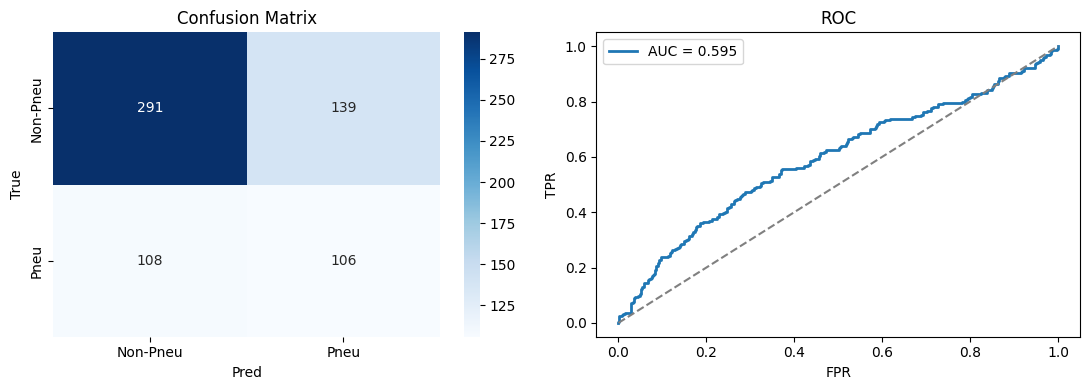


Classification report:
              precision    recall  f1-score   support

    Non-Pneu       0.73      0.68      0.70       430
        Pneu       0.43      0.50      0.46       214

    accuracy                           0.62       644
   macro avg       0.58      0.59      0.58       644
weighted avg       0.63      0.62      0.62       644



In [16]:
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)

results = pd.DataFrame([{
    "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "AUC-ROC": auc
}]).T.rename(columns={0: "Value"})
print(results.round(4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Pneu", "Pneu"], yticklabels=["Non-Pneu", "Pneu"], ax=axes[0])
axes[0].set_title("Confusion Matrix"); axes[0].set_xlabel("Pred"); axes[0].set_ylabel("True")

# ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr, tpr, label=f"AUC = {auc:.3f}", lw=2)
axes[1].plot([0,1],[0,1], "--", color="gray")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].set_title("ROC")
axes[1].legend()
plt.tight_layout(); plt.show()

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=["Non-Pneu", "Pneu"]))

### Honest interpretation

NIH pneumonia is **hard**. A reasonable result on this dataset is AUC ~0.70–0.80; published baselines (e.g., CheXNet) get ~0.77 AUC on the pneumonia label specifically. If you're below 0.65 AUC, the model is barely learning; above 0.85 you're probably overfitting or have a data leak. The paper's 99.35% does NOT transfer to this dataset.

## 9. Explainability — 4 Techniques

We pick 4 test images for explanation: 2 correctly classified + 2 misclassified. Misclassified cases are more informative for XAI than correct ones.

In [17]:
test_df_indexed = test_df.reset_index(drop=True)
test_paths = test_df_indexed["path"].tolist()

correct_idx = np.where(y_pred == y_true)[0]
wrong_idx = np.where(y_pred != y_true)[0]

# Pick 2 correct (one of each class) + 2 wrong (one of each error type if available)
def pick(idx_pool, condition, n=1):
    eligible = [i for i in idx_pool if condition(i)]
    return eligible[:n]

explain_indices = []
explain_indices += pick(correct_idx, lambda i: y_true[i] == 1, n=1)  # true pos
explain_indices += pick(correct_idx, lambda i: y_true[i] == 0, n=1)  # true neg
explain_indices += pick(wrong_idx,   lambda i: y_true[i] == 1, n=1)  # false neg
explain_indices += pick(wrong_idx,   lambda i: y_true[i] == 0, n=1)  # false pos

print(f"Selected {len(explain_indices)} samples for XAI:")
for i in explain_indices:
    tag = "CORRECT" if y_pred[i] == y_true[i] else "WRONG"
    print(f"  idx={i}  true={int(y_true[i])}  pred={int(y_pred[i])}  prob={y_prob[i]:.3f}  [{tag}]")

# Pre-load the actual image tensors (CLAHE-preprocessed) for each
def load_clahe(path):
    img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img, dtype=np.float32)
    return clahe_preprocess(arr)  # returns float32 in [0, 1]

explain_imgs = np.stack([load_clahe(test_paths[i]) for i in explain_indices])  # (N, H, W, 3)
print(f"Image tensor shape: {explain_imgs.shape}")

Selected 4 samples for XAI:
  idx=9  true=1  pred=1  prob=0.560  [CORRECT]
  idx=1  true=0  pred=0  prob=0.439  [CORRECT]
  idx=0  true=1  pred=0  prob=0.488  [WRONG]
  idx=4  true=0  pred=1  prob=0.563  [WRONG]
Image tensor shape: (4, 224, 224, 3)


### 9.1 Grad-CAM (gradient-based localization)

Hooks the last Conv2D layer (`conv3`) and weights its feature maps by gradients of the output w.r.t. those features.

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_image']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0021568629890680313..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0021568629890680313..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.004313725978136063..1.000000011920929].


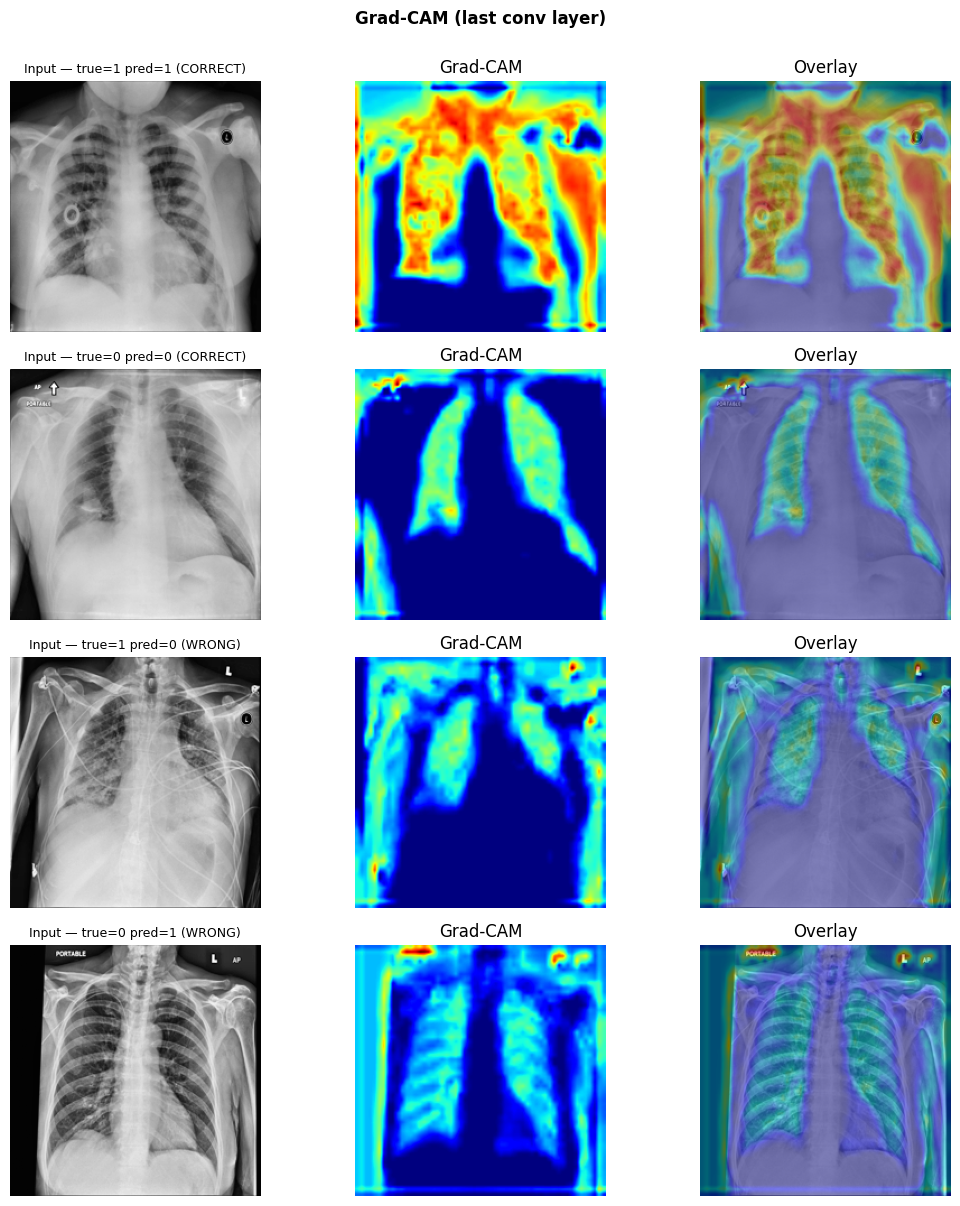

In [18]:
def grad_cam(model, img_array, layer_name="conv3"):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )
    img_tensor = tf.convert_to_tensor(img_array[None, ...])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_tensor)
        loss = preds[:, 0]
    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]
    heatmap = conv_out @ pooled_grads[..., None]
    heatmap = tf.squeeze(heatmap).numpy()
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()
    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    return heatmap

fig, axes = plt.subplots(len(explain_indices), 3, figsize=(11, 3 * len(explain_indices)))
for row, i in enumerate(explain_indices):
    img = explain_imgs[row]
    cam = grad_cam(model, img)
    cam_color = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    cam_color = cv2.cvtColor(cam_color, cv2.COLOR_BGR2RGB) / 255.0
    overlay = 0.55 * img + 0.45 * cam_color

    tag = "CORRECT" if y_pred[i] == y_true[i] else "WRONG"
    title = f"true={int(y_true[i])} pred={int(y_pred[i])} ({tag})"
    axes[row][0].imshow(img); axes[row][0].set_title(f"Input — {title}", fontsize=9); axes[row][0].axis("off")
    axes[row][1].imshow(cam, cmap="jet"); axes[row][1].set_title("Grad-CAM"); axes[row][1].axis("off")
    axes[row][2].imshow(overlay); axes[row][2].set_title("Overlay"); axes[row][2].axis("off")
plt.suptitle("Grad-CAM (last conv layer)", fontsize=12, fontweight="bold", y=1.001)
plt.tight_layout(); plt.show()

### 9.2 LIME (superpixel-based perturbation)

LIME segments the image into superpixels, randomly hides subsets of them, and learns a local linear model around the prediction.

In [19]:
!pip install -q lime

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

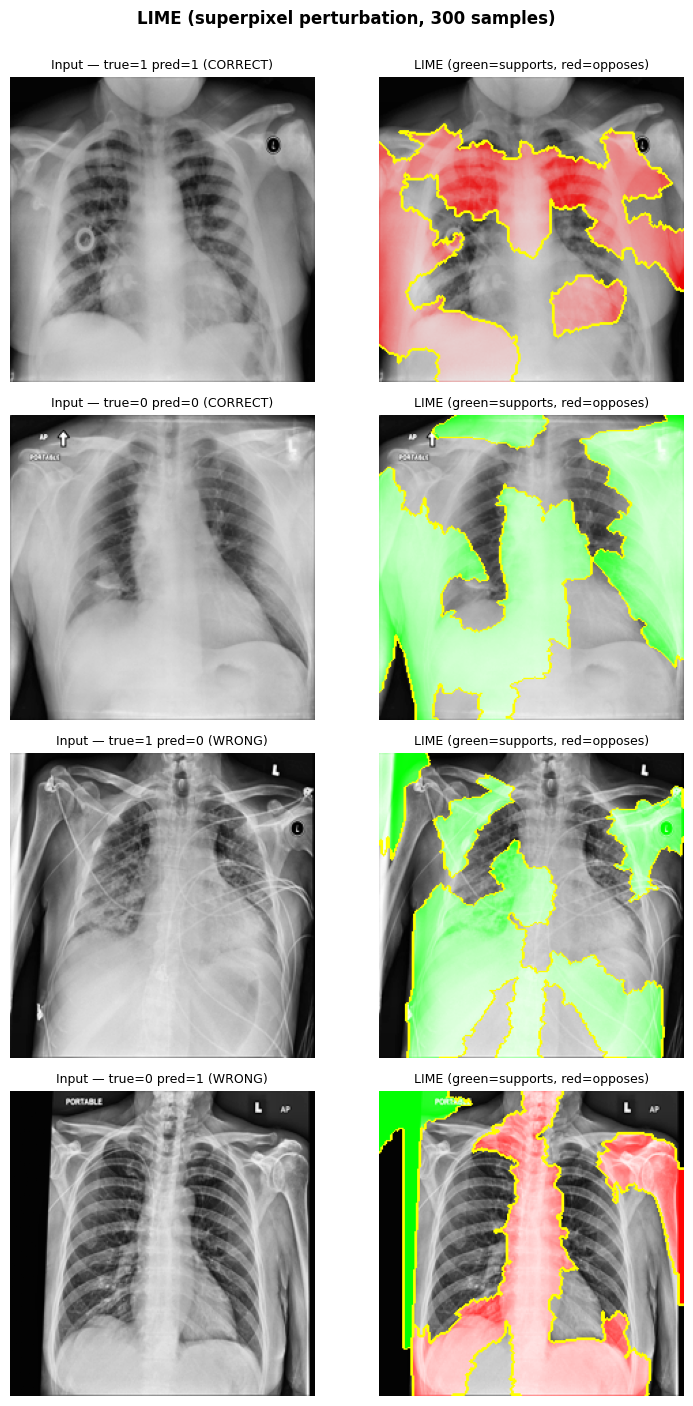

In [20]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

def keras_predict_fn(images):
    # images: (N, H, W, 3) uint8 or float in [0, 1]
    if images.dtype == np.uint8:
        images = images.astype(np.float32) / 255.0
    # Apply CLAHE consistently
    processed = np.stack([clahe_preprocess((im * 255).astype(np.uint8)) for im in images])
    probs_pos = model.predict(processed, verbose=0).flatten()
    # LIME expects (N, n_classes)
    return np.stack([1 - probs_pos, probs_pos], axis=1)

explainer_lime = lime_image.LimeImageExplainer()

fig, axes = plt.subplots(len(explain_indices), 2, figsize=(8, 3.5 * len(explain_indices)))
for row, i in enumerate(explain_indices):
    img = explain_imgs[row]
    explanation = explainer_lime.explain_instance(
        img.astype(np.double),
        keras_predict_fn,
        top_labels=2, hide_color=0, num_samples=300, random_seed=SEED,
    )
    pred_class = int(y_pred[i])
    temp, mask = explanation.get_image_and_mask(
        pred_class, positive_only=False, num_features=8, hide_rest=False
    )
    boundary = mark_boundaries(temp / (temp.max() if temp.max() > 1 else 1), mask)

    tag = "CORRECT" if y_pred[i] == y_true[i] else "WRONG"
    axes[row][0].imshow(img); axes[row][0].axis("off")
    axes[row][0].set_title(f"Input — true={int(y_true[i])} pred={pred_class} ({tag})", fontsize=9)
    axes[row][1].imshow(boundary); axes[row][1].axis("off")
    axes[row][1].set_title("LIME (green=supports, red=opposes)", fontsize=9)
plt.suptitle("LIME (superpixel perturbation, 300 samples)", fontsize=12, fontweight="bold", y=1.001)
plt.tight_layout(); plt.show()

### 9.3 SHAP — GradientExplainer

Shapley-style attributions via expected gradients with a background distribution sampled from training data.

In [21]:
!pip install -q shap

In [ ]:
import shap

# Background: ~20 random training images
bg_idx = np.random.RandomState(SEED).choice(len(train_df), 20, replace=False)
bg_imgs = np.stack([load_clahe(train_df.iloc[i]["path"]) for i in bg_idx])

explainer_shap = shap.GradientExplainer(model, bg_imgs)
shap_values = explainer_shap.shap_values(explain_imgs)

# shap_values shape varies by SHAP version: list of (N,H,W,C) per class, or single (N,H,W,C) or (N,H,W,C,1)
if isinstance(shap_values, list):
    sv = shap_values[0]
else:
    sv = shap_values
sv = np.array(sv)
if sv.ndim == 5:  # (N, H, W, C, 1)
    sv = sv[..., 0]

print(f"SHAP attribution shape: {sv.shape}")

fig, axes = plt.subplots(len(explain_indices), 2, figsize=(8, 3.5 * len(explain_indices)))
for row, i in enumerate(explain_indices):
    attr = sv[row].sum(axis=-1)  # collapse channels
    vmax = np.abs(attr).max() + 1e-8

    tag = "CORRECT" if y_pred[i] == y_true[i] else "WRONG"
    axes[row][0].imshow(explain_imgs[row]); axes[row][0].axis("off")
    axes[row][0].set_title(f"Input — true={int(y_true[i])} pred={int(y_pred[i])} ({tag})", fontsize=9)
    axes[row][1].imshow(attr, cmap="seismic", vmin=-vmax, vmax=vmax); axes[row][1].axis("off")
    axes[row][1].set_title("SHAP (red=supports, blue=opposes)", fontsize=9)
plt.suptitle("SHAP GradientExplainer", fontsize=12, fontweight="bold", y=1.001)
plt.tight_layout(); plt.show()

### 9.4 Integrated Gradients

Integrates the model's gradients along a straight-line path from a zero baseline to the actual input. Satisfies completeness and sensitivity axioms that vanilla saliency does not.

Implemented from scratch in TensorFlow (50 steps, Riemann sum approximation).

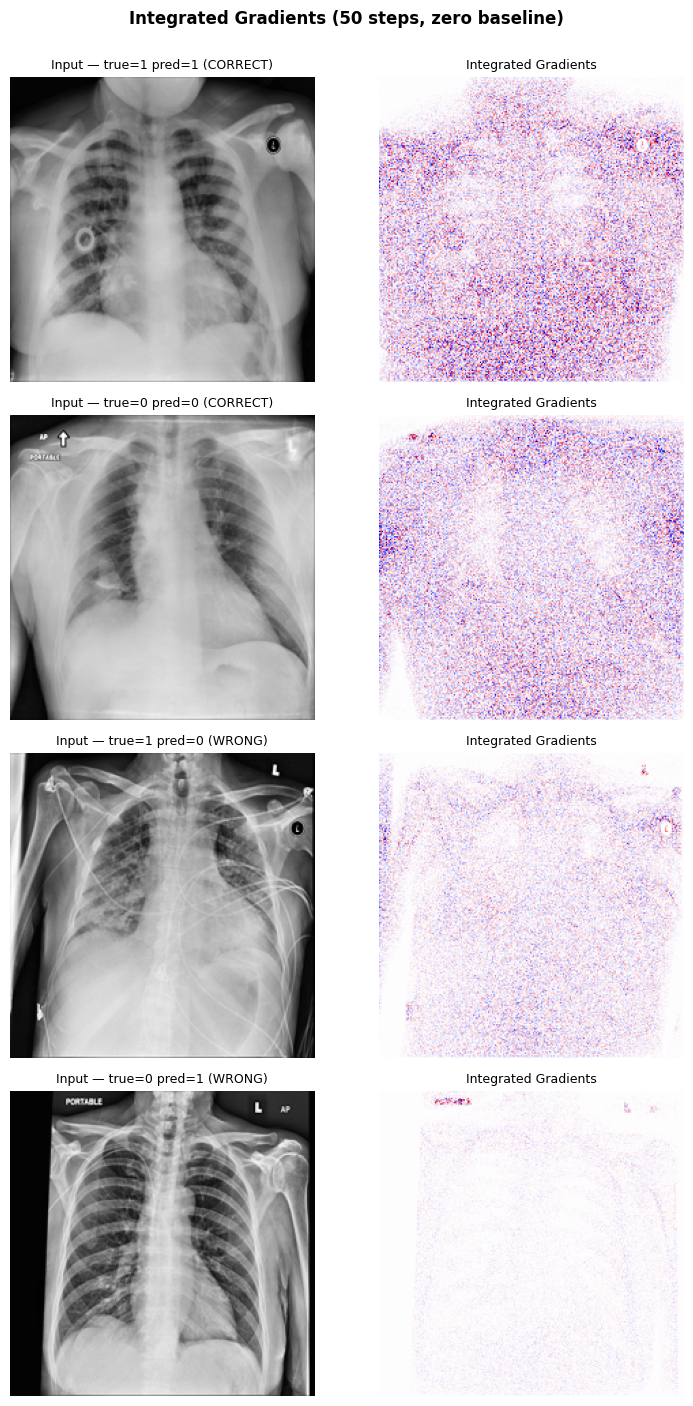

In [23]:
def integrated_gradients(model, img, baseline=None, steps=50):
    if baseline is None:
        baseline = np.zeros_like(img)
    # Generate interpolations
    alphas = np.linspace(0, 1, steps).reshape(-1, 1, 1, 1).astype(np.float32)
    interp = baseline + alphas * (img - baseline)  # (steps, H, W, 3)
    interp_t = tf.convert_to_tensor(interp)

    with tf.GradientTape() as tape:
        tape.watch(interp_t)
        preds = model(interp_t)[:, 0]
    grads = tape.gradient(preds, interp_t).numpy()   # (steps, H, W, 3)
    avg_grads = (grads[:-1] + grads[1:]) / 2.0       # trapezoidal
    avg_grads = avg_grads.mean(axis=0)               # (H, W, 3)
    ig = (img - baseline) * avg_grads                # (H, W, 3)
    return ig

fig, axes = plt.subplots(len(explain_indices), 2, figsize=(8, 3.5 * len(explain_indices)))
for row, i in enumerate(explain_indices):
    ig = integrated_gradients(model, explain_imgs[row], steps=50)
    attr = ig.sum(axis=-1)
    vmax = np.abs(attr).max() + 1e-8

    tag = "CORRECT" if y_pred[i] == y_true[i] else "WRONG"
    axes[row][0].imshow(explain_imgs[row]); axes[row][0].axis("off")
    axes[row][0].set_title(f"Input — true={int(y_true[i])} pred={int(y_pred[i])} ({tag})", fontsize=9)
    axes[row][1].imshow(attr, cmap="seismic", vmin=-vmax, vmax=vmax); axes[row][1].axis("off")
    axes[row][1].set_title("Integrated Gradients", fontsize=9)
plt.suptitle("Integrated Gradients (50 steps, zero baseline)", fontsize=12, fontweight="bold", y=1.001)
plt.tight_layout(); plt.show()

## 10. Cross-Method XAI Comparison & Honest Limitations

### What to look for when reading these explanations

- **Agreement across methods** = strong evidence the model is using that region. If Grad-CAM, LIME, SHAP, and IG all highlight the same lung area, that's robust.
- **Disagreement** = the explanation is fragile and shouldn't be trusted clinically.
- **On misclassified cases**: attribution often shows the model focused on the wrong thing (e.g., ribcage edges, text artifacts). This is the most useful diagnostic XAI provides.

### Limitations to flag in your viva

1. **All four methods are post-hoc, correlation-based.** They show where the model looks, not why its reasoning is medically valid. A radiologist would need to confirm clinical relevance.

2. **NIH "Pneumonia" labels are weak.** Even perfect explanations of a high-accuracy model would be explanations of decisions about noisy labels.

3. **CLAHE preprocessing affects attribution.** The methods explain the model's behavior on CLAHE-enhanced inputs, not raw X-rays. If you wanted to explain decisions on raw inputs, CLAHE would need to be inside the model.

4. **Image-level (not patient-level) split** means some test images may share a patient with training images, inflating test metrics. A `GroupShuffleSplit` on `Patient ID` would be more rigorous and likely lower scores.

5. **No baseline comparison.** A more complete XAI study would also test a simpler model (e.g., logistic regression on CNN features) to show whether the BiGRU + Attention adds genuine improvement or just complexity.

## 11. Save Final Artifacts

In [25]:
import json

results_dict = {
    "framework": "TensorFlow/Keras",
    "dataset": "NIH ChestX-ray14 (balanced 2:1 subset)",
    "deviations_from_paper": [
        "Different dataset (NIH vs Kaggle Paul Mooney)",
        "No SNN component (no production Keras SNN library)",
        "Image-level split (not patient-level)",
    ],
    "test_accuracy": float(acc),
    "test_precision": float(prec),
    "test_recall": float(rec),
    "test_f1": float(f1),
    "test_auc": float(auc),
    "train_size": int(len(train_df)),
    "val_size": int(len(val_df)),
    "test_size": int(len(test_df)),
    "xai_techniques": ["Grad-CAM", "LIME", "SHAP GradientExplainer", "Integrated Gradients"],
}
with open(os.path.join(CHECKPOINT_DIR, "results.json"), "w") as f:
    json.dump(results_dict, f, indent=2)
print(json.dumps(results_dict, indent=2))
print(f"\nArtifacts saved to: {CHECKPOINT_DIR}")

{
  "framework": "TensorFlow/Keras",
  "dataset": "NIH ChestX-ray14 (balanced 2:1 subset)",
  "deviations_from_paper": [
    "Different dataset (NIH vs Kaggle Paul Mooney)",
    "No SNN component (no production Keras SNN library)",
    "Image-level split (not patient-level)"
  ],
  "test_accuracy": 0.6164596273291926,
  "test_precision": 0.4326530612244898,
  "test_recall": 0.4953271028037383,
  "test_f1": 0.46187363834422657,
  "test_auc": 0.5950228211258421,
  "train_size": 3005,
  "val_size": 644,
  "test_size": 644,
  "xai_techniques": [
    "Grad-CAM",
    "LIME",
    "SHAP GradientExplainer",
    "Integrated Gradients"
  ]
}

Artifacts saved to: /kaggle/working
